In [53]:
import pandas as pd
import numpy as np
import json
import re
from pathlib import Path
from typing import Set, List, Dict

## 1. Import data

In [54]:
vnexpress_foods = pd.read_csv('vnexpress_foods_detail.csv')
vnexpress_foods.head()

,link,type_of_food,title,description,author_name,cook_time,num_of_people,calories,num_of_ingredients,ingredients,step,note,post_date
0,https://vnexpress.net/doi-song-cooking-cach-mu...,Món Tết,Cách muối dưa hành truyền thống,Dưa hành muối là món ăn truyền thống ngày Tết ...,Bùi Thủy,45 phút,8-10 người,459 kcal,5,"['1 kg hành củ tươi', 'Tro bếp hoặc nước vo gọ...",['Bước 1: Chọn hành củ: Nên chọn hành củ ta bá...,[],"Thứ năm, 23/1/2025, 16:32 (GMT+7)"
1,https://vnexpress.net/doi-song-cooking-su-hao-...,Món Tết,Su hào xào mực - món cổ Tết Bát Tràng,Đĩa xào khô ráo với su hào giòn ngọt quyện với...,Bùi Thủy,50 phút,4 - 5 người,1.162 kcal,6,"['2 củ su hào non', '1 con mực khô', '1/2 củ c...",['Bước 1: Chọn và sơ chế mực: Người dân làng g...,['Su hào xào mực cùng với canh măng mực là hai...,"Thứ sáu, 17/1/2025, 17:24 (GMT+7)"
2,https://vnexpress.net/doi-song-cooking-canh-ma...,Món Tết,Canh măng ngày Tết cổ truyền Hà Nội,"Măng ngấu vị, giòn ngon, móng giò hầm vừa độ s...",Bùi Thủy,100 phút,8 - 10 người,4.930 kcal,6,"['800 gr măng khô', '2 móng giò lợn', 'Nước dù...","['Bước 1: Chọn măng khô: Theo lối cũ, người nộ...",['Nếu tận dụng nước luộc gà nấu canh măng thì ...,"Thứ tư, 15/1/2025, 19:00 (GMT+7)"
3,https://vnexpress.net/doi-song-cooking-gia-han...,Món Tết,Giả hạnh nhân - món ngon Tết xưa Hà Nội,Đây là món ăn cổ truyền thường thấy trong cỗ T...,Bùi Thủy,60 phút,4-5 người,1.112 kcal,8,"['2 bộ lòng mề gà', '100 gr lạc', '50 gr hạt đ...",['Bước 1: Chọn và sơ chế lạc: Chọn lạc khô chắ...,['Hạnh nhân xào (hay giả hạnh nhân) là món ăn ...,"Thứ ba, 7/1/2025, 17:31 (GMT+7)"
4,https://vnexpress.net/doi-song-cooking-cha-bi-...,Món Tết,Chả bì ớt xiêm xanh,"Chả bì bóng đẹp, gói đều tay. Khi ăn vị ngọt m...",Bùi Thủy,60 phút,5-6 người,2.512 kcal,6,"['500 gr giò sống', '300 gr bì lợn', '20 - 30 ...","['Bước 1: Chọn và sơ chế bì lợn, chuẩn bị giò ...",['Nên sơ chế kỹ bì lợn để chả được thơm. Tùy t...,"Thứ ba, 31/12/2024, 18:00 (GMT+7)"


In [55]:
vncooking_foods = pd.read_csv('vncooking_final_data.csv')
vncooking_foods.head()

,link,type_of_food,title,description,author_name,cook_time,num_of_people,calories,num_of_ingredients,ingredients,step,note,post_date
0,https://vncooking.com/cong-thuc/tom-hap-lien-h...,Món chính,Tôm hấp liên hoa,Tôm hấp liên hoa không chỉ có hình thức bắt mắ...,NaN,30phút,2,NaN,3,"['tôm thẻ 200 gam', 'giò sống 500 gam', 'Hành ...",['Bước 1: Sơ chế nguyên liệu Tôm mua về bóc vỏ...,[],"Thứ năm, 19/10/2023, 20:08 (GMT+7)"
1,https://vncooking.com/cong-thuc/tra-lipton-pha...,Thức uống,Trà Lipton pha với 7up,Đã bao giờ bạn thử món nước giải khát được làm...,NaN,15phút,2,NaN,2,"['trà Lipton 1 túi', '7up 1 chai']","['Bước 1: Pha chế trà Lipton với 7up Đầu tiên,...",[],"Thứ hai, 16/10/2023, 20:11 (GMT+7)"
2,https://vncooking.com/cong-thuc/cach-lam-kem-s...,Bánh và bánh ngọt,Cách làm kem sầu riêng thơm ngon nhanh cấp tốc...,Bạn đã biết cách làm kem sầu riêng thơm ngon g...,NaN,30phút,2,NaN,4,"['Thịt sầu riêng 100 gam', 'Sữa đặc 50 gam', '...","['Bước 1: Sơ chế nguyên liệu Đầu tiên, bạn cho...",[],"Chủ nhật, 15/10/2023, 22:15 (GMT+7)"
3,https://vncooking.com/cong-thuc/cach-lam-bun-g...,Món chính,"Cách làm bún gà lá é ngọt thơm, chua thanh cho...",xin giới thiệu đến bạn món bún gà lá é với hươ...,NaN,45phút,2,NaN,3,"['thịt gà ta 800 gam', 'lá é 400 gam', 'Bún 30...",['Bước 1: Sơ chế nguyên liệu Thịt gà mua về bạ...,[],"Chủ nhật, 8/10/2023, 20:32 (GMT+7)"
4,https://vncooking.com/cong-thuc/khoai-tay-nghi...,Bánh và bánh ngọt,Khoai tây nghiền phô mai cấp tốc bằng snack kh...,Bạn có thể tự làm khoai tây nghiền phô mai tại...,NaN,15phút,2,NaN,2,"['Snack khoai tây 1 ống', 'Sữa tươi không đườn...","['Bước 1: Sơ chế nguyên liệu Đầu tiên, bạn hãy...",[],"Thứ năm, 5/10/2023, 22:08 (GMT+7)"


In [56]:
dienmayxanh_foods = pd.read_csv('dienmayxanh_foods_detail.csv')
dienmayxanh_foods.head()

,link,type_of_food,title,description,author_name,cook_time,num_of_people,calories,num_of_ingredients,ingredients,step,note,post_date
0,https://www.dienmayxanh.com/vao-bep/cach-nau-g...,Món canh,Cách hầm gà lá ngải bằng nồi cơm điện đậm đà b...,Nếu bạn cần một gợi ý cho một món từ gà thơm n...,NaN,90 phút,3 người,NaN,7,"['1 con Gà (khoảng 1.3 kg)', '1 củ Gừng', '50 ...",['Bước 1: Sơ chế nguyên liệu: Gà bạn làm sạch ...,['Xem chi tiết: Cách chọn mua thịt gà tươi ngo...,NaN
1,https://www.dienmayxanh.com/vao-bep/cach-nau-s...,Món canh,Cách nấu súp nấm cần tây dễ làm dễ ăn thơm nức...,Cần tây là nguyên liệu quen thuộc trong nấu ăn...,NaN,30 phút,5 người,NaN,11,"['500 gr Nấm mỡ', '3 nhánh Cần tây', '1 củ Hàn...","['Bước 1: Sơ chế nguyên liệu: Đầu tiên, cần tâ...",['Cần tây là gì ? Cách phân biệt cần tây Tác d...,NaN
2,https://www.dienmayxanh.com/vao-bep/cach-nau-s...,Món canh,Cách nấu súp cua chay thơm ngon đơn giản cho n...,Thế giới ẩm thực chay có vô vàn những món ăn n...,NaN,90 phút,7 người,NaN,15,"['1 trái Bắp Mỹ', '1 củ Cà rốt', '1 củ Củ sắn'...","['Bước 1: Sơ chế nguyên liệu: Bắp lột vỏ, rửa ...",['Xem thêm:'],NaN
3,https://www.dienmayxanh.com/vao-bep/cach-nau-g...,Món canh,2 cách nấu giò heo hầm củ cải muối và bắp chuố...,"Các món canh với chân giò hầm cực kì bổ dưỡng,...",NaN,40 phút,4 người,NaN,9,"['1.5 kg Giò heo', '400 gr Củ cải muối (3 - 4 ...","['Bước 1: Sơ chế giò heo: Giò heo khi mua về, ...",['Xem chi tiết: Cách làm củ cải muối (xá bấu) ...,NaN
4,https://www.dienmayxanh.com/vao-bep/cach-nau-c...,Món canh,"Cách nấu canh cá minh thái Hàn Quốc bổ dưỡng, ...","Những ngày trời mưa se lạnh, còn gì tuyệt vời ...",NaN,30 phút,4 người ăn,NaN,17,"['700 gr Cá minh thái', '50 gr Cải cúc', '2 mi...",['Bước 1: Sơ chế cá minh thái: Cá minh thái mu...,['Xem chi tiết: Cách làm bột ớt Hàn Quốc ngon ...,NaN


## 2. Check data type and merge

In [57]:
# Kiểm tra thông tin cơ bản của từng dataframe
print("=" * 80)
print("VNEXPRESS FOODS")
print("=" * 80)
print(f"Shape: {vnexpress_foods.shape}")
print(f"\nColumns: {vnexpress_foods.columns.tolist()}")
print(f"\nData types:\n{vnexpress_foods.dtypes}")
print(f"\nMissing values:\n{vnexpress_foods.isnull().sum()}")

print("=" * 80)
print("VNCOOKING FOODS")
print("=" * 80)
print(f"Shape: {vncooking_foods.shape}")
print(f"\nColumns: {vncooking_foods.columns.tolist()}")
print(f"\nData types:\n{vncooking_foods.dtypes}")
print(f"\nMissing values:\n{vncooking_foods.isnull().sum()}")

print("=" * 80)
print("DIENMAYXANH FOODS")
print("=" * 80)
print(f"Shape: {dienmayxanh_foods.shape}")
print(f"\nColumns: {dienmayxanh_foods.columns.tolist()}")
print(f"\nData types:\n{dienmayxanh_foods.dtypes}")
print(f"\nMissing values:\n{dienmayxanh_foods.isnull().sum()}")

VNEXPRESS FOODS
Shape: (810, 13)

Columns: ['link', 'type_of_food', 'title', 'description', 'author_name', 'cook_time', 'num_of_people', 'calories', 'num_of_ingredients', 'ingredients', 'step', 'note', 'post_date']

Data types:
link                  object
type_of_food          object
title                 object
description           object
author_name           object
cook_time             object
num_of_people         object
calories              object
num_of_ingredients     int64
ingredients           object
step                  object
note                  object
post_date             object
dtype: object

Missing values:
link                    0
type_of_food            0
title                   0
description             0
author_name           349
cook_time             363
num_of_people         364
calories              372
num_of_ingredients      0
ingredients             0
step                    0
note                    0
post_date               0
dtype: int64
VNCOOKING FOO

## 3. Merge all dataframes

In [58]:
# Thêm cột source để biết dữ liệu từ nguồn nào
vnexpress_foods['source'] = 'vnexpress'
vncooking_foods['source'] = 'vncooking'
dienmayxanh_foods['source'] = 'dienmayxanh'

# Merge tất cả dataframes (concat theo chiều dọc)
all_recipes = pd.concat([vnexpress_foods, vncooking_foods, dienmayxanh_foods], 
                         axis=0, 
                         ignore_index=True)

print(f"Tổng số công thức sau khi merge: {len(all_recipes)}")
print(f"Shape: {all_recipes.shape}")
print(f"\nSố lượng từng nguồn:")
print(all_recipes['source'].value_counts())

Tổng số công thức sau khi merge: 11492
Shape: (11492, 14)

Số lượng từng nguồn:
source
dienmayxanh    10138
vnexpress        810
vncooking        544
Name: count, dtype: int64


In [59]:
# Xem thông tin tổng quan sau merge
all_recipes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11492 entries, 0 to 11491
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   link                11492 non-null  object
 1   type_of_food        11492 non-null  object
 2   title               11492 non-null  object
 3   description         11485 non-null  object
 4   author_name         461 non-null    object
 5   cook_time           11129 non-null  object
 6   num_of_people       11128 non-null  object
 7   calories            438 non-null    object
 8   num_of_ingredients  11492 non-null  int64 
 9   ingredients         11492 non-null  object
 10  step                11492 non-null  object
 11  note                11492 non-null  object
 12  post_date           1354 non-null   object
 13  source              11492 non-null  object
dtypes: int64(1), object(13)
memory usage: 1.2+ MB


In [60]:
all_recipes.sample(5)

,link,type_of_food,title,description,author_name,cook_time,num_of_people,calories,num_of_ingredients,ingredients,step,note,post_date,source
1457,https://www.dienmayxanh.com/vao-bep/cach-nau-c...,Món canh,"Cách nấu canh chua cá basa ngon thơm béo, dinh...",Canh chua cá basa với hương vị mang đậm tính m...,NaN,15 phút,2 người,NaN,12,"['500 gr Cá basa', '3 trái Cà chua', '100 gr G...",['Bước 1: Sơ chế cá basa: Cá ba sa làm sạch ma...,['Xem thêm: Cá basa bao nhiêu calo? Ăn cá basa...,NaN,dienmayxanh
10071,https://www.dienmayxanh.com/vao-bep/lam-thit-h...,Ăn vặt,Cách làm thịt heo khô xé sợi rim mắm ngon đậm ...,"Món khô sẽ là món nhâm nhi cực chất, đúng điệu...",NaN,30 phút,4 người,NaN,9,['500 gr Thịt heo (bạn nên chọn miếng thịt heo...,['Bước 1: Chế biến thịt heo: Thịt heo rửa sạch...,['Xem thêm'],NaN,dienmayxanh
9289,https://www.dienmayxanh.com/vao-bep/cach-lam-c...,Món gỏi - salad,Cách làm chạo tai heo đơn giản hấp dẫn mới lạ ...,Chạo tai heo là món gỏi trộn dân dã được yêu t...,NaN,25 phút,4 người,NaN,12,"['350 gr Tai heo', '80 gr Riềng băm nhuyễn', '...",['Bước 1: Sơ chế và áp chảo tai heo: Tai heo m...,"['Xem thêm: Cách chọn mua, sơ chế và cách làm ...",NaN,dienmayxanh
6465,https://www.dienmayxanh.com/vao-bep/cach-lam-o...,Món xào,Cách làm ốc móng tay xào bơ tỏi ngon miệng thơ...,Ốc móng tay là loại hải sản rất được ưa chuộng...,NaN,15 phút,4 người,NaN,9,"['400 gr Ốc móng tay', '1 củ Tỏi', '3 quả Ớt',...",['Bước 1: Sơ chế ốc móng tay và các nguyên liệ...,['Xem chi tiết: Cách làm bơ lạt đơn giản dễ dà...,NaN,dienmayxanh
9660,https://www.dienmayxanh.com/vao-bep/cach-lam-t...,Món chay,Cách làm tàu hủ non sốt tương hột thơm ngon đậ...,Đậu hũ non là một món ăn giàu giá trị dinh dưỡ...,NaN,15 phút,2 người,NaN,8,"['300 gr Đậu hũ non', '20 gr Tương hột', '50 g...",['Bước 1: Sơ chế nguyên liệu phụ: Nấm mèo sau ...,['Xem chi tiết: Cách làm đậu hũ non đơn giản t...,NaN,dienmayxanh


## 4. Exploratory Data Analysis (EDA)

MISSING VALUES ANALYSIS
                                Column  Missing_Count  Missing_Percentage
calories                      calories          11054               96.19
author_name                author_name          11031               95.99
post_date                    post_date          10138               88.22
num_of_people            num_of_people            364                3.17
cook_time                    cook_time            363                3.16
description                description              7                0.06
title                            title              0                0.00
type_of_food              type_of_food              0                0.00
link                              link              0                0.00
num_of_ingredients  num_of_ingredients              0                0.00
ingredients                ingredients              0                0.00
step                              step              0                0.00
note          

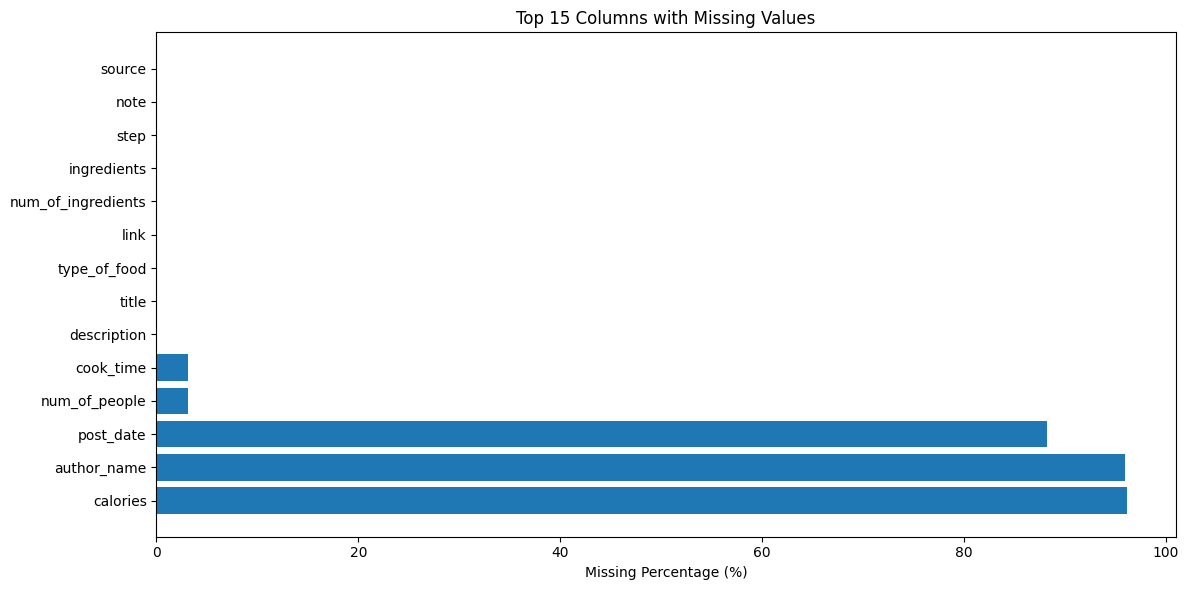

In [61]:
# 4.1. Missing values analysis
print("=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)

missing_stats = pd.DataFrame({
    'Column': all_recipes.columns,
    'Missing_Count': all_recipes.isnull().sum(),
    'Missing_Percentage': (all_recipes.isnull().sum() / len(all_recipes) * 100).round(2)
}).sort_values('Missing_Percentage', ascending=False)

print(missing_stats)

# Visualize missing values
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
missing_stats_top = missing_stats.head(15)
plt.barh(missing_stats_top['Column'], missing_stats_top['Missing_Percentage'])
plt.xlabel('Missing Percentage (%)')
plt.title('Top 15 Columns with Missing Values')
plt.tight_layout()
plt.show()

In [62]:
# 4.2. Phân tích các cột quan trọng

# Title
print("\n--- TITLE ---")
print(f"Total recipes: {all_recipes['title'].notna().sum()}")
print(f"Missing titles: {all_recipes['title'].isna().sum()}")
print(f"Sample titles:\n{all_recipes['title'].dropna().head(3).tolist()}")

# Type of food
print("\n--- TYPE OF FOOD ---")
if 'type_of_food' in all_recipes.columns:
    print(f"Top 10 loại món ăn phổ biến:")
    print(all_recipes['type_of_food'].value_counts().head(10))
else:
    print("Column 'type_of_food' không tồn tại")

# Ingredients
print("\n--- INGREDIENTS ---")
print(f"Recipes có ingredients: {all_recipes['ingredients'].notna().sum()}")
print(f"Recipes không có ingredients: {all_recipes['ingredients'].isna().sum()}")

# Steps
print("\n--- STEPS ---")
print(f"Recipes có steps: {all_recipes['step'].notna().sum()}")
print(f"Recipes không có steps: {all_recipes['step'].isna().sum()}")


--- TITLE ---
Total recipes: 11492
Missing titles: 0
Sample titles:
['Cách muối dưa hành truyền thống', 'Su hào xào mực - món cổ Tết Bát Tràng', 'Canh măng ngày Tết cổ truyền Hà Nội']

--- TYPE OF FOOD ---
Top 10 loại món ăn phổ biến:
type_of_food
Món bánh              2254
Món chiên              981
Món xào                929
Món canh               648
Món kho                643
Thức uống              592
Ăn vặt                 569
Món hấp                528
Món ngon hàng ngày     414
Món nướng              413
Name: count, dtype: int64

--- INGREDIENTS ---
Recipes có ingredients: 11492
Recipes không có ingredients: 0

--- STEPS ---
Recipes có steps: 11492
Recipes không có steps: 0


In [63]:
# 4.3. Kiểm tra trùng lặp
print("DUPLICATE ANALYSIS")

# Duplicate based on title
print(f"\nTotal recipes: {len(all_recipes)}")
print(f"Duplicate titles: {all_recipes['title'].duplicated().sum()}")
print(f"Unique titles: {all_recipes['title'].nunique()}")

# Xem một vài ví dụ duplicate
if all_recipes['title'].duplicated().sum() > 0:
    print("\n--- Sample duplicate titles ---")
    dup_titles = all_recipes[all_recipes['title'].duplicated(keep=False)].sort_values('title')
    for title in dup_titles['title'].unique()[:3]:
        print(f"\n'{title}':")
        print(dup_titles[dup_titles['title'] == title][['title', 'source']].to_string(index=False))

DUPLICATE ANALYSIS

Total recipes: 11492
Duplicate titles: 12
Unique titles: 11480

--- Sample duplicate titles ---

'Canh chua cá lóc':
           title    source
Canh chua cá lóc vncooking
Canh chua cá lóc vncooking

'Chè bưởi':
   title    source
Chè bưởi vnexpress
Chè bưởi vnexpress

'Chè ngô cốm':
      title    source
Chè ngô cốm vnexpress
Chè ngô cốm vnexpress


In [64]:
# 4.4. Data quality check - Recipes hoàn chỉnh
print("DATA QUALITY CHECK")

# Recipes có đầy đủ thông tin cơ bản (title, ingredients, steps)
complete_recipes = all_recipes[
    (all_recipes['title'].notna()) & 
    (all_recipes['ingredients'].notna()) & 
    (all_recipes['step'].notna())
]

print(f"\nRecipes hoàn chỉnh (có title, ingredients, steps): {len(complete_recipes)}/{len(all_recipes)} ({len(complete_recipes)/len(all_recipes)*100:.2f}%)")

print("\n--- Quality by source ---")
for source in all_recipes['source'].unique():
    source_total = len(all_recipes[all_recipes['source'] == source])
    source_complete = len(complete_recipes[complete_recipes['source'] == source])
    print(f"{source.upper()}: {source_complete}/{source_total} ({source_complete/source_total*100:.2f}%)")

DATA QUALITY CHECK

Recipes hoàn chỉnh (có title, ingredients, steps): 11492/11492 (100.00%)

--- Quality by source ---
VNEXPRESS: 810/810 (100.00%)
VNCOOKING: 544/544 (100.00%)
DIENMAYXANH: 10138/10138 (100.00%)


## 5. Preprocess data

In [65]:
# Tạo bản copy để preprocess
df_clean = all_recipes.copy()

print(f"Bắt đầu với {len(df_clean)} recipes")
print(f"Số cột: {len(df_clean.columns)}")

Bắt đầu với 11492 recipes
Số cột: 14


In [66]:
# 5.0. Xóa các cột có quá nhiều missing values (>50%)
columns_to_drop = ["author_name", "post_date"]

df_clean = all_recipes.drop(columns=columns_to_drop, errors="ignore")

print("Remaining columns:", df_clean.columns.tolist())


Remaining columns: ['link', 'type_of_food', 'title', 'description', 'cook_time', 'num_of_people', 'calories', 'num_of_ingredients', 'ingredients', 'step', 'note', 'source']


In [67]:
# 5.1. Xóa các dòng trùng lặp dựa trên title
print(f"Trước khi xóa: {len(df_clean)} recipes")
print(f"Số title trùng: {df_clean['title'].duplicated().sum()}")

# Giữ lại recipe đầu tiên, xóa các bản duplicate sau
df_clean = df_clean.drop_duplicates(subset=['title'], keep='first')

print(f"Sau khi xóa: {len(df_clean)} recipes")
print(f"Đã xóa {len(all_recipes) - len(df_clean)} recipes trùng lặp")

Trước khi xóa: 11492 recipes
Số title trùng: 12
Sau khi xóa: 11480 recipes
Đã xóa 12 recipes trùng lặp


In [68]:
# 5.2. Xóa tất cả các sample có dạng "2 cách nấu, 3 cách làm,..."
import re

# Regex nhận diện title dạng "<số> cách ..."
pattern = r'^\s*\d+\s+cách\b'

# Lọc các sample match pattern
mask_numeric_prefix = df_clean['title'].astype(str).str.lower().str.match(pattern)

# Đếm trước khi xóa
count_to_drop = mask_numeric_prefix.sum()
print("Số lượng sample sẽ bị xóa:", count_to_drop)

# Tiến hành xóa
df_clean = df_clean[~mask_numeric_prefix].reset_index(drop=True)

print("Dữ liệu sau khi xóa:", len(df_clean))


Số lượng sample sẽ bị xóa: 1145
Dữ liệu sau khi xóa: 10335


In [69]:
# 5.3. Xử lý cột title - Xóa "Cách làm", "Cách nấu" ở đầu chuỗi

# Kiểm tra trước khi xử lý
print("Sample titles trước khi xử lý:")
print(df_clean['title'].head(10).tolist())

# Hàm để clean title
def clean_title(title):
    if pd.isna(title):
        return title

    title = str(title).strip()

    # Remove all double quotes
    title = title.strip('"').strip("'").strip("“").strip("”").strip("‘").strip("’")

    # Remove patterns như "4 cách làm", "2 cách làm", "3 cách nấu"
    title = re.sub(r'^\s*\d+\s+cách\s+(làm|nấu|chế biến|pha)\s+', '', title, flags=re.IGNORECASE)

    # Remove known prefixes
    prefixes = [
        'Cách làm ',
        'Cách nấu ',
        'Cách chế biến ',
        'Cách pha ',
        'Hướng dẫn làm ',
        'Hướng dẫn nấu ',
        'Công thức làm ',
        'Công thức nấu ',
    ]

    for prefix in prefixes:
        if title.lower().startswith(prefix.lower()):
            title = title[len(prefix):].strip()
            break

    # Capitalize first letter
    if title:
        title = title[0].upper() + title[1:]

    return title

# Áp dụng cleaning
df_clean['title'] = df_clean['title'].apply(clean_title)

print("\nSample titles sau khi xử lý:")
print(df_clean['title'].head(10).tolist())

Sample titles trước khi xử lý:
['Cách muối dưa hành truyền thống', 'Su hào xào mực - món cổ Tết Bát Tràng', 'Canh măng ngày Tết cổ truyền Hà Nội', 'Giả hạnh nhân - món ngon Tết xưa Hà Nội', 'Chả bì ớt xiêm xanh', 'Mọc đông - món ngon Tết Hà Nội xưa', 'Cách làm chạo chân giò - món ngon Tết vùng Hà Nam Ninh', 'Cách làm nem rán kiểu truyền thống miền Bắc', 'Cách gói giò mỡ - đặc sản Tết Thái Bình', 'Cách làm thịt kho hột vịt truyền thống miền Tây']

Sample titles sau khi xử lý:
['Cách muối dưa hành truyền thống', 'Su hào xào mực - món cổ Tết Bát Tràng', 'Canh măng ngày Tết cổ truyền Hà Nội', 'Giả hạnh nhân - món ngon Tết xưa Hà Nội', 'Chả bì ớt xiêm xanh', 'Mọc đông - món ngon Tết Hà Nội xưa', 'Chạo chân giò - món ngon Tết vùng Hà Nam Ninh', 'Nem rán kiểu truyền thống miền Bắc', 'Cách gói giò mỡ - đặc sản Tết Thái Bình', 'Thịt kho hột vịt truyền thống miền Tây']


In [70]:
# 5.4. Xóa các recipes không có thông tin cơ bản (title, ingredients, steps)

print(f"Trước khi filter: {len(df_clean)} recipes")

# Filter chỉ giữ lại recipes có đủ thông tin cơ bản
df_clean = df_clean[
    (df_clean['title'].notna()) & 
    (df_clean['title'].str.strip() != '') &
    (df_clean['ingredients'].notna()) & 
    (df_clean['step'].notna())
].copy()

print(f"Sau khi filter: {len(df_clean)} recipes")
print(f"Đã xóa {len(all_recipes) - len(df_clean)} recipes thiếu thông tin")

Trước khi filter: 10335 recipes
Sau khi filter: 10335 recipes
Đã xóa 1157 recipes thiếu thông tin


In [71]:
# 5.5 Kiểm tra các recipes không có step
print("RECIPES WITHOUT STEPS")

# Tìm các recipes không có step (bao gồm NaN, empty string, và '[]')
no_steps = df_clean[
    df_clean['step'].isna() | 
    (df_clean['step'].astype(str).str.strip() == '') |
    (df_clean['step'].astype(str).str.strip() == '[]')
]

print(f"Số lượng recipes không có step: {len(no_steps)}")
print(f"Phần trăm: {len(no_steps)/len(df_clean)*100:.2f}%")

if len(no_steps) > 0:
    print("\n--- Sample recipes không có step")
    print(no_steps[['title']].head(10))
    
    print("\n--- Phân bố theo source")
    print(no_steps['source'].value_counts())

RECIPES WITHOUT STEPS
Số lượng recipes không có step: 72
Phần trăm: 0.70%

--- Sample recipes không có step
                                  title
221                 Vài món Âu đơn giản
226      Những món ngon cho mùa heo may
227                   3 món ngon dễ làm
230               Biến tấu với món canh
231            Các món ăn đậm hương quê
232              Hai món ngon chữa bệnh
235                    Biến tấu món gan
236                     Quen lạ với tôm
238      Hai món ngày thường ngon miệng
239  Hai món ngon mang vị ngọt cam thảo

--- Phân bố theo source
source
vnexpress    69
vncooking     3
Name: count, dtype: int64


In [72]:
# 5.5 Xóa các recipes không có step
print(f"Trước khi xóa: {len(df_clean)} recipes")

# Xóa các recipes không có step (bao gồm NaN, empty string, và '[]')
df_clean = df_clean[
    (df_clean['step'].notna()) & 
    (df_clean['step'].astype(str).str.strip() != '') &
    (df_clean['step'].astype(str).str.strip() != '[]')
].copy()

print(f"Sau khi xóa: {len(df_clean)} recipes")
print(f"Đã xóa {len(no_steps)} recipes không có step")

# Reset index
df_clean = df_clean.reset_index(drop=True)

Trước khi xóa: 10335 recipes
Sau khi xóa: 10263 recipes
Đã xóa 72 recipes không có step


## 6. Preprocess ingredient

### 6.1. Analyze Quantity Patterns in Ingredients

In [73]:
# Sample ingredients to identify quantity patterns
for idx in range(min(10, len(df_clean))):
    ingredients = df_clean.iloc[idx]['ingredients']
    if pd.notna(ingredients):
        # Split and show first few items
        items = [item.strip() for item in re.split(r'[,;\n]', ingredients) if item.strip()]
        for i, item in enumerate(items[:3]):
            print(f"  {item}")
        if idx < 9:
            print()

# Common quantity patterns in Vietnamese
quantity_patterns = [
    r'\d+\s*(gram|g|kg|kilogram)',  # 100 gram, 500g, 1kg
    r'\d+\s*(ml|lít|liter)',  # 200ml, 1 lít
    r'\d+\s*(muỗng|thìa)',  # 2 muỗng, 3 thìa
    r'\d+\s*con',  # 1 con, 2 con
    r'\d+\s*củ',  # 3 củ
    r'\d+\s*quả',  # 2 quả
    r'\d+\s*(cái|chiếc)',  # 5 cái
    r'nửa\s*\w+',  # nửa con, nửa kg
    r'một\s*ít',  # một ít
    r'\d+/\d+',  # 1/2, 1/4
    r'\d+',  # Any standalone numbers
]

  ['1 kg hành củ tươi'
  'Tro bếp hoặc nước vo gọa'
  'Muối hạt

  ['2 củ su hào non'
  '1 con mực khô'
  '1/2 củ cà rốt'

  ['800 gr măng khô'
  '2 móng giò lợn'
  'Nước dùng (gà hoặc ninh xương lợn)'

  ['2 bộ lòng mề gà'
  '100 gr lạc'
  '50 gr hạt đậu Hà Lan'

  ['500 gr giò sống'
  '300 gr bì lợn'
  '20 - 30 gr ớt xiêm xanh'

  ['300 gr giò sống'
  '200 gr nạc vai'
  '200 gr bì thăn'

  ['500 gr thịt chân giò'
  '4 cây sả'
  '4 tép tỏi'

  ['500 gr thịt nạc vai'
  '200 gr giá đỗ'
  '2 lòng đỏ trứng gà'

  ['1
  5 kg thịt ba chỉ liền khối'
  '5 củ hành khô'

  ['1 kg thịt ba rọi (ba chỉ rút sườn)'
  '10 quả trứng vịt'
  'Nước dừa tươi'


### 6.2. Remove Quantities from Ingredients

In [74]:
def remove_quantities(text: str) -> str:
    """
    "100g thịt bò" -> "thịt bò", "1 con gà" -> "gà"
    """
    if pd.isna(text) or not isinstance(text, str):
        return ""
    
    # Convert to lowercase first
    text = text.lower()
    
    # Remove ALL quotes, brackets, and parentheses
    text = text.replace("'", "").replace('"', "").replace('[', '').replace(']', '')
    text = text.replace('(', '').replace(')', '')
    
    # Define quantity patterns (Vietnamese specific)
    patterns_to_remove = [
        # Fractions FIRST (before other number patterns) - remove entire fraction
        r'\d+/\d+',
        
        # Measurements with units (including "cà phê" for teaspoon)
        r'\d+[\.,]?\d*\s*(gram|gr|g|kg|kilogram|kí|ký)\s*',
        r'\d+[\.,]?\d*\s*(ml|mililít|lít|liter|l)\s*',
        r'\d+[\.,]?\d*\s*(muỗng|thìa)\s*(cà\s*phê|canh)?\s*',
        r'\d+[\.,]?\d*\s*(mcf|mct)\s*',
        r'\d+[\.,]?\d*\s*(chén|bát|tô|ly|cốc)\s*',
        
        # Counters
        r'\d+[\.,]?\d*\s*(con|cái|chiếc|củ|quả|trái|trứng|lát|miếng|khúc|đốt|nhánh|cây|bông|tép|nắm)\s*',
        
        # Vietnamese number words + quantity
        r'(một|hai|ba|bốn|năm|sáu|bảy|tám|chín|mười)\s+(ít|chút|tí|vài)\s*',
        r'\d+\s+(ít|chút|tí|vài)\s*',
        
        # Descriptors
        r'nửa\s+\w*\s*',
        r'một\s+(ít|chút|tí)\s*',
        r'vài\s+\w*\s*',
        
        # Standalone numbers with spaces
        r'^\d+[\.,]?\d*\s+',
        r'\s+\d+[\.,]?\d*\s+',
        r'\s+\d+[\.,]?\d*$',
    ]
    
    # Apply all patterns
    for pattern in patterns_to_remove:
        text = re.sub(pattern, ' ', text, flags=re.IGNORECASE)
    
    # Clean up extra whitespace and trim
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Remove leading/trailing special characters (but parentheses already removed)
    text = re.sub(r'^[^\w\sáàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵđ]+', '', text)
    text = re.sub(r'[^\w\sáàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵđ]+$', '', text)
    
    return text.strip()

# Test the function with problematic cases
test_cases = [
    "100 gram bắp non",
    "' r bắp non'",
    "'1 ít gia vị thông dụng (đường/ muối/ hạt nêm/ tiêu xay)'",
    "'1 ít hành ngò'",
    "'100gr bơ lạt'",
    "2 muỗng cà phê đường",
    "3 muỗng canh nước mắm",
    "1 muỗng tiêu",
    "nửa kg cà chua",
    "500ml nước mắm",
    "3 củ hành tây",
    "10gr thịt bò",
    "2 nhánh hành lá",
    "1 bông cải xanh",
    "3 tép tỏi",
    "1 nắm rau muống",
    "200g thịt băm",
    "1/2 quả chanh",
    "1/4 chén nước",
    "vài lát gừng",
    "bakingsoda (bột nở)",
    "dầu ăn (hoặc bơ)",
]

for test in test_cases:
    cleaned = remove_quantities(test)
    print(f"  Original: {test:55} -> Cleaned: '{cleaned}'")

In [75]:
# normalize function
def normalize_ingredients(ingredients_str: str) -> Set[str]:
    if pd.isna(ingredients_str) or not isinstance(ingredients_str, str):
        return set()
    
    # Split first by separators
    normalized = re.sub(r'[,;\n]+', '|', ingredients_str)
    tokens = normalized.split('|')
    
    # Remove quantities from each token
    cleaned_tokens = []
    for token in tokens:
        cleaned = remove_quantities(token)
        if cleaned and len(cleaned) > 1:  # Only keep non-empty tokens with more than 1 char
            cleaned_tokens.append(cleaned)
    
    return set(cleaned_tokens)

### 6.3. Apply Normalization

In [76]:
# Apply the improved normalization function
df_clean['ingredients_normalized'] = df_clean['ingredients'].apply(normalize_ingredients)

for idx in range(min(3, len(df_clean))):
    original = df_clean.iloc[idx]['ingredients']
    norm = df_clean.iloc[idx]['ingredients_normalized']
    
    print(f"Recipe {idx}:")
    print(f"  Original: {original}")
    print(f"  Normalized: {list(norm)}\n")

Recipe 0:
  Original: ['1 kg hành củ tươi', 'Tro bếp hoặc nước vo gọa', 'Muối hạt, đường', 'Cà rốt trang trí (tùy chọn)', 'Lọ sạch']
  Normalized: ['tro bếp hoặc nước vo gọa', 'đường', 'cà rốt trang trí tùy chọn', 'hành củ tươi', 'lọ sạch', 'muối hạt']

Recipe 1:
  Original: ['2 củ su hào non', '1 con mực khô', '1/2 củ cà rốt', 'Gia vị: Mắm, muối, đường, hạt tiêu, rượu trắng, gừng', 'Rau mùi trang trí', 'Mỡ lợn hoặc dầu ăn']
  Normalized: ['muối', 'mỡ lợn hoặc dầu ăn', 'đường', 'gia vị: mắm', 'mực khô', 'rượu trắng', 'gừng', 'hạt tiêu', 'củ cà rốt', 'su hào non', 'rau mùi trang trí']

Recipe 2:
  Original: ['800 gr măng khô', '2 móng giò lợn', 'Nước dùng (gà hoặc ninh xương lợn)', 'Hành khô, hành củ', 'Gia vị: Nước mắm truyền thống, muối', 'Nước vo gạo ngâm măng']
  Normalized: ['muối', 'móng giò lợn', 'nước vo gạo ngâm măng', 'hành củ', 'nước dùng gà hoặc ninh xương lợn', 'hành khô', 'gia vị: nước mắm truyền thống', 'măng khô']



## 7. Save data

In [77]:
# Reset index
df_clean = df_clean.reset_index(drop=True)

# Định nghĩa thứ tự cột
meta_cols = [
    'title', 'type_of_food', 'link'
]

content_cols = [
    'description', 'ingredients', 'ingredients_normalized', 'step', 'note'
]

numeric_cols = [
    'num_of_ingredients', 'num_steps', 'cook_time', 'num_of_people', 'calories'
]

# Toàn bộ cột còn lại
remaining_cols = [c for c in df_clean.columns 
                  if c not in meta_cols + content_cols + numeric_cols]

# Gộp final columns
ordered_cols = meta_cols + content_cols + numeric_cols + remaining_cols

# Apply ordering
df_clean = df_clean[[c for c in ordered_cols if c in df_clean.columns]]

print("Final column order:")
for i, col in enumerate(df_clean.columns, 1):
    print(f"{i:2d}. {col}")


Final column order:
 1. title
 2. type_of_food
 3. link
 4. description
 5. ingredients
 6. ingredients_normalized
 7. step
 8. note
 9. num_of_ingredients
10. cook_time
11. num_of_people
12. calories
13. source


In [78]:
# Lưu dữ liệu đã preprocessing
df_clean.to_csv('all_recipes_final.csv', index=False)
print(f"Đã lưu {len(df_clean)} recipes vào 'all_recipes_final.csv'")

# # Lưu thêm file JSON để dễ dàng load lại (giữ nguyên cấu trúc list)
# import json

# # Convert DataFrame to list of dicts
# recipes_json = df_clean.to_dict('records')

# with open('all_recipes_final.json', 'w', encoding='utf-8') as f:
#     json.dump(recipes_json, f, ensure_ascii=False, indent=2)

# print(f"Đã lưu {len(df_clean)} recipes vào 'all_recipes_final.json'")

Đã lưu 10263 recipes vào 'all_recipes_final.csv'
